In [ ]:
from google.colab import files
uploaded =files.upload()

Saving customer_shopping_behavior (1).csv to customer_shopping_behavior (1).csv


In [ ]:
import pandas as pd
df=pd.read_csv("customer_shopping_behavior (1).csv")

In [ ]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [ ]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [ ]:
df['Review Rating'] = df['Review Rating'].fillna(df.groupby('Category')['Review Rating'].transform('median'))

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [ ]:
df.columns=df.columns.str.lower().str.replace(" ","_")

In [ ]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [ ]:
labels=['child','young','adult']
df['age_group']=pd.qcut(df["age"],q=3,labels=labels)

In [ ]:
df[['age','age_group']].head(10)

,age,age_group
0,55,adult
1,19,child
2,50,young
3,21,child
4,45,young
5,46,young
6,63,adult
7,27,child
8,26,child
9,57,adult


In [ ]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [ ]:
(df['promo_code_used']==df['discount_applied']).all()

np.True_

In [ ]:
df.drop('promo_code_used', axis=1, inplace=True)

In [ ]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group'],
      dtype='object')

In [ ]:
import sqlite3

In [ ]:
conn = sqlite3.connect('customer_shopping_behavior.db')

,gender,revenue
0,Female,75191
1,Male,157890


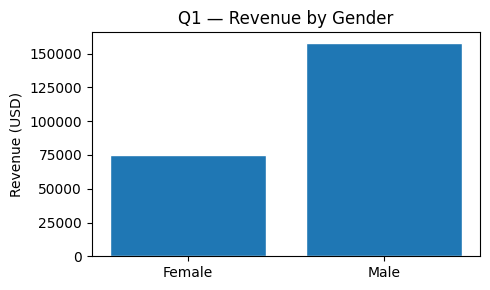

In [ ]:
import matplotlib.pyplot as plt

# Save the DataFrame to a SQLite table named 'customer'
df.to_sql('customer', conn, if_exists='replace', index=False)

q1 = pd.read_sql("""
    SELECT gender,
           SUM("purchase_amount_(usd)") AS revenue
    FROM   customer
    GROUP  BY gender
""", conn)

display(q1)

plt.figure(figsize=(5,3))
plt.bar(q1['gender'], q1['revenue'], edgecolor='white')
plt.title('Q1 — Revenue by Gender')
plt.ylabel('Revenue (USD)')
plt.tight_layout(); plt.show()

In [ ]:
q2 = pd.read_sql("""
    SELECT customer_id,
           "purchase_amount_(usd)"
    FROM   customer
    WHERE  UPPER(discount_applied) = 'YES'
      AND  "purchase_amount_(usd)" >= (SELECT AVG("purchase_amount_(usd)") FROM customer)
    ORDER  BY "purchase_amount_(usd)" DESC
""", conn)

print(f'Customers found: {len(q2)}')
display(q2.head(10))

Customers found: 839


,customer_id,purchase_amount_(usd)
0,43,100
1,96,100
2,194,100
3,205,100
4,244,100
5,249,100
6,456,100
7,519,100
8,582,100
9,616,100


,item_purchased,avg_product_rating
0,Gloves,3.86
1,Sandals,3.84
2,Boots,3.82
3,Hat,3.80
4,T-shirt,3.78


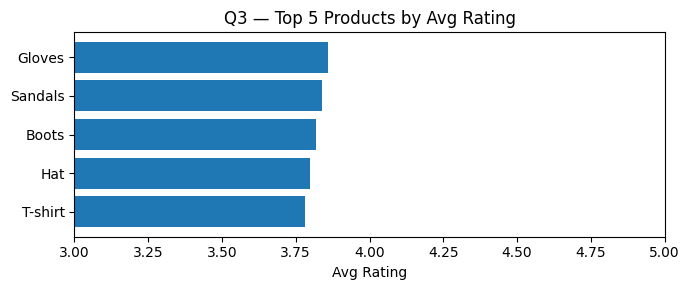

In [ ]:
q3 = pd.read_sql("""
    SELECT item_purchased,
           ROUND(AVG(review_rating), 2) AS avg_product_rating
    FROM   customer
    GROUP  BY item_purchased
    ORDER  BY avg_product_rating DESC
    LIMIT  5
""", conn)

display(q3)

plt.figure(figsize=(7,3))
plt.barh(q3['item_purchased'][::-1], q3['avg_product_rating'][::-1])
plt.xlim(3, 5)
plt.xlabel('Avg Rating')
plt.title('Q3 — Top 5 Products by Avg Rating')
plt.tight_layout(); plt.show()

,shipping_type,avg_purchase_amount
0,Express,60.48
1,Standard,58.46


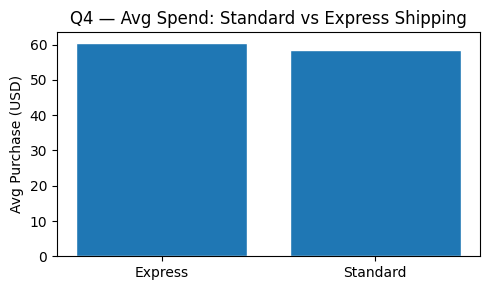

In [ ]:
q4 = pd.read_sql("""
    SELECT shipping_type,
           ROUND(AVG("purchase_amount_(usd)"), 2) AS avg_purchase_amount
    FROM   customer
    WHERE  shipping_type IN ('Standard', 'Express')
    GROUP  BY shipping_type
""", conn)

display(q4)

plt.figure(figsize=(5,3))
plt.bar(q4['shipping_type'], q4['avg_purchase_amount'], edgecolor='white')
plt.title('Q4 — Avg Spend: Standard vs Express Shipping')
plt.ylabel('Avg Purchase (USD)')
plt.tight_layout(); plt.show()

,subscription_status,total_customers,avg_spend,total_revenue
0,No,2847,59.87,170436.0
1,Yes,1053,59.49,62645.0


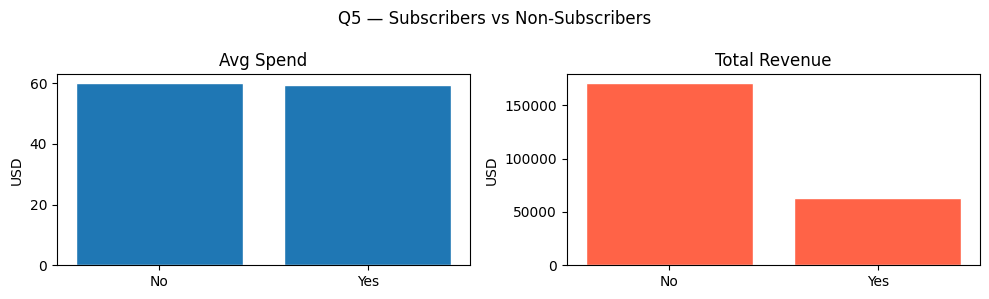

In [ ]:
q5 = pd.read_sql("""
    SELECT subscription_status,
           COUNT(customer_id)             AS total_customers,
           ROUND(AVG("purchase_amount_(usd)"), 2) AS avg_spend,
           ROUND(SUM("purchase_amount_(usd)"), 2) AS total_revenue
    FROM   customer
    GROUP  BY subscription_status
    ORDER  BY total_revenue DESC, avg_spend DESC
""", conn)

display(q5)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].bar(q5['subscription_status'], q5['avg_spend'], edgecolor='white')
axes[0].set_title('Avg Spend')
axes[0].set_ylabel('USD')
axes[1].bar(q5['subscription_status'], q5['total_revenue'], edgecolor='white', color='tomato')
axes[1].set_title('Total Revenue')
axes[1].set_ylabel('USD')
fig.suptitle('Q5 — Subscribers vs Non-Subscribers', fontsize=12)
plt.tight_layout(); plt.show()

,item_purchased,discount_rate_pct
0,Hat,50.00
1,Sneakers,49.66
2,Coat,49.07
3,Sweater,48.17
4,Pants,47.37


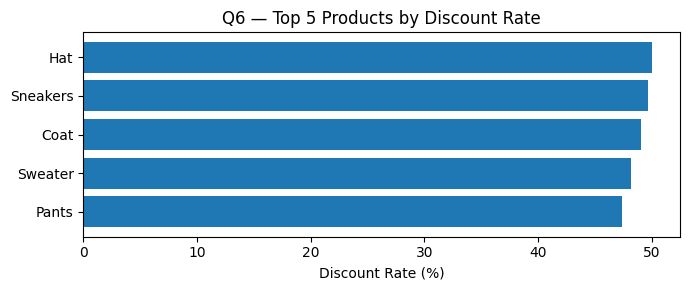

In [ ]:
q6 = pd.read_sql("""
    SELECT item_purchased,
           ROUND(
               100.0 * SUM(CASE WHEN UPPER(discount_applied) = 'YES' THEN 1 ELSE 0 END)
               / COUNT(*), 2
           ) AS discount_rate_pct
    FROM   customer
    GROUP  BY item_purchased
    ORDER  BY discount_rate_pct DESC
    LIMIT  5
""", conn)

display(q6)

plt.figure(figsize=(7,3))
plt.barh(q6['item_purchased'][::-1], q6['discount_rate_pct'][::-1])
plt.xlabel('Discount Rate (%)')
plt.title('Q6 — Top 5 Products by Discount Rate')
plt.tight_layout(); plt.show()

,customer_segment,number_of_customers
0,Loyal,3116
1,Returning,701
2,New,83


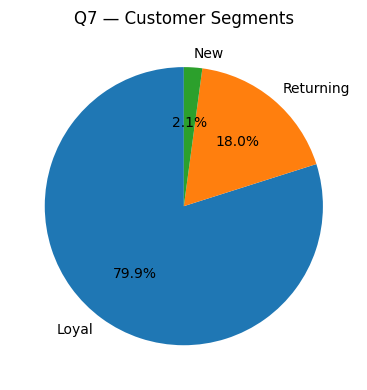

In [ ]:
q7 = pd.read_sql("""
    WITH customer_type AS (
        SELECT customer_id,
               previous_purchases,
               CASE
                   WHEN previous_purchases = 1           THEN 'New'
                   WHEN previous_purchases BETWEEN 2 AND 10 THEN 'Returning'
                   ELSE 'Loyal'
               END AS customer_segment
        FROM   customer
    )
    SELECT customer_segment,
           COUNT(*) AS number_of_customers
    FROM   customer_type
    GROUP  BY customer_segment
    ORDER  BY number_of_customers DESC
""", conn)

display(q7)

plt.figure(figsize=(5,4))
plt.pie(q7['number_of_customers'], labels=q7['customer_segment'],
        autopct='%1.1f%%', startangle=90)
plt.title('Q7 — Customer Segments')
plt.tight_layout(); plt.show()

,item_rank,category,item_purchased,total_orders
0,1,Accessories,Jewelry,171
1,2,Accessories,Sunglasses,161
2,3,Accessories,Belt,161
3,1,Clothing,Pants,171
4,2,Clothing,Blouse,171
5,3,Clothing,Shirt,169
6,1,Footwear,Sandals,160
7,2,Footwear,Shoes,150
8,3,Footwear,Sneakers,145
9,1,Outerwear,Jacket,163


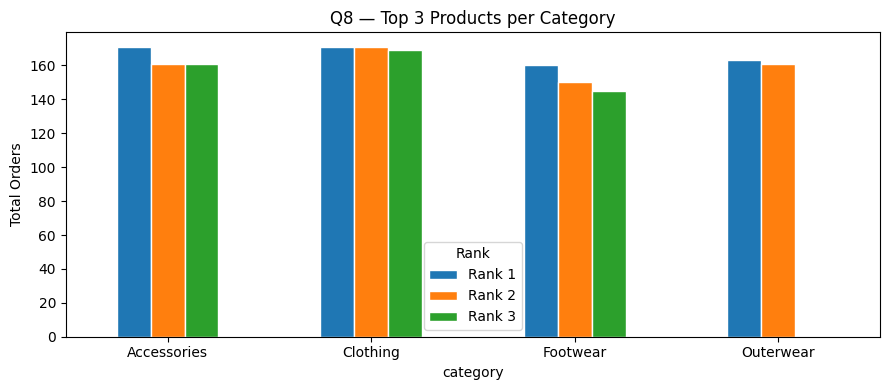

In [ ]:
q8 = pd.read_sql("""
    WITH item_counts AS (
        SELECT category,
               item_purchased,
               COUNT(customer_id) AS total_orders,
               ROW_NUMBER() OVER (
                   PARTITION BY category
                   ORDER BY COUNT(customer_id) DESC
               ) AS item_rank
        FROM   customer
        GROUP  BY category, item_purchased
    )
    SELECT item_rank,
           category,
           item_purchased,
           total_orders
    FROM   item_counts
    WHERE  item_rank <= 3
    ORDER  BY category, item_rank
""", conn)

display(q8)

# Grouped bar chart
pivot8 = q8.pivot(index='category', columns='item_rank', values='total_orders')
pivot8.columns = ['Rank 1', 'Rank 2', 'Rank 3']
pivot8.plot(kind='bar', figsize=(9, 4), rot=0, edgecolor='white')
plt.title('Q8 — Top 3 Products per Category')
plt.ylabel('Total Orders')
plt.legend(title='Rank')
plt.tight_layout(); plt.show()

,subscription_status,repeat_buyers
0,No,2518
1,Yes,958


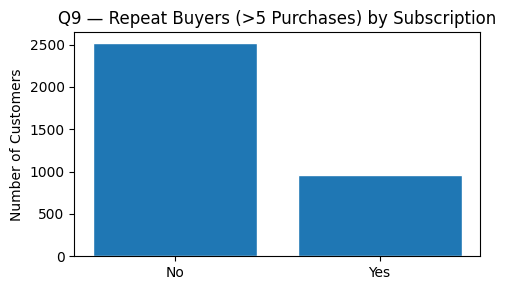

In [ ]:
q9 = pd.read_sql("""
    SELECT subscription_status,
           COUNT(customer_id) AS repeat_buyers
    FROM   customer
    WHERE  previous_purchases > 5
    GROUP  BY subscription_status
""", conn)

display(q9)

plt.figure(figsize=(5,3))
plt.bar(q9['subscription_status'], q9['repeat_buyers'], edgecolor='white')
plt.title('Q9 — Repeat Buyers (>5 Purchases) by Subscription')
plt.ylabel('Number of Customers')
plt.tight_layout(); plt.show()

In [ ]:
q10 = pd.read_sql("""
    SELECT
        age_group,
        SUM("purchase_amount_(usd)") AS total_revenue
    FROM customer
    GROUP BY age_group
    ORDER BY total_revenue DESC;
""", conn)

display(q10)

,age_group,total_revenue
0,young,79237
1,child,78972
2,adult,74872
